**Notebook Feito por:** MSc. Eng. Paulo de Souza Silva  
**Data:** Agosto de 2026  
**Conteúdo retirado e adaptado de livros e artigos sobre Galerkin Descontínuo**  
**Agradecimentos:** Um agradecimento ao Prof. Dr. Alberto Nogueira pela disponibilização dos scripts em Python para DG 1D

# **Integradores Numéricos**

Nas aulas anteriores, dedicamos um esforço considerável para construir e entender cada engrenagem da nossa discretização espacial. Passamos pela base polinomial, pelas quadraturas de integração, invertemos a matriz de massa, aplicamos a projeção de fluxos para controlar o aliasing e garantimos a comunicação entre os elementos através dos fluxos numéricos nas fronteiras.O resultado de todo esse trabalho culminou em uma única e poderosa expressão computacional, o nosso operador espacial $L_h$:

$$L_h = \frac{1}{J_e} \left[\int_{\Omega_{pd}} \phi_i \phi_j d \xi \right]^{-1} \left ( \int_{\Omega_{pd}} f \dfrac{\partial}{\partial \xi} \begin{Bmatrix} \phi_0 \\ \phi_1 \\ \vdots \\ \phi_P \end{Bmatrix} d \xi-  \tilde{f}_{e,e+1} \begin{Bmatrix} \phi^+_0 \\ \phi^+_1 \\ \vdots \\ \phi^+_P \end{Bmatrix} +  \tilde{f}_{e-1,e}\begin{Bmatrix} \phi^-_0 \\ \phi^-_1 \\ \vdots \\ \phi^-_P \end{Bmatrix} \right )$$

> **Mas o que fazemos com isso agora?**

Se observarmos atentamente, ao resolver as integrais espaciais, nós eliminamos a dependência contínua da variável espacial $x$ (ou $\xi$). O que nos resta é a variação dos nossos graus de liberdade (os coeficientes $\{c_i\}$) exclusivamente no tempo.

Isso significa que transformamos a nossa Equação Diferencial Parcial (EDP) original em um gigantesco sistema acoplado de Equações Diferenciais Ordinárias (EDOs). Se definirmos o vetor de coeficientes do nosso sistema como $\mathbf{U} = \{c_0, c_1, \dots, c_P\}^T$, podemos reescrever a equação governante de forma incrivelmente compacta:

$$\frac{d\mathbf{U}}{dt} = L_h(\mathbf{U}, t)$$

Este conceito é conhecido como Método das Linhas (Method of Lines). A beleza dessa abordagem é a separação de interesses: a partir deste ponto, o integrador temporal é "cego" em relação à física. Ele não precisa saber se $\mathbf{U}$ representa a Equação de Burgers invíscida, as Equações de Euler ou uma simples equação de advecção escalar. Toda a física, as condições de contorno e o tratamento de choques estão encapsulados dentro da "caixa preta" chamada $L_h$.Nosso objetivo agora é avançar o vetor de coeficientes $\mathbf{U}$ de um tempo $t^n$ para um tempo futuro $t^{n+1} = t^n + \Delta t$.

## **Método de Euler**

### **Introdução ao Método de Euler**

A forma mais intuitiva de avançar no tempo é olhar para a definição mais fundamental do cálculo: a expansão em Série de Taylor. Se conhecemos o estado do nosso sistema em um tempo $t^n$, o estado num pequeno instante futuro $t^{n+1} = t^n + \Delta t$ pode ser escrito como:

$$\mathbf{U}(t^{n+1}) = \mathbf{U}(t^n) + \Delta t \frac{d\mathbf{U}}{dt}\bigg\vert{}_{t^n} + \frac{\Delta t^2}{2!} \frac{d^2\mathbf{U}}{dt^2}\bigg\vert{}_{t^n} + \mathcal{O}(\Delta t^3)$$

Se assumirmos que o nosso passo de tempo $\Delta t$ é suficientemente pequeno, os termos de alta ordem ($\Delta t^2$, $\Delta t^3 \dots$) tornam-se desprezíveis. Ao truncarmos a série no termo linear, obtemos o clássico Método de Euler (Explícito).

Lembrando que no nosso método DG a derivada temporal é exatamente o nosso operador espacial computado no instante atual $\left( \frac{d\mathbf{U}}{dt} = L_h(\mathbf{U}^n) \right)$, chegamos à expressão:

$$\mathbf{U}^{n+1} = \mathbf{U}^n + \Delta t L_h(\mathbf{U}^n)$$

Em termos dos coeficientes que apresentamos na Aula 00, isso equivale a escrever:

$$\{c_i\}^{(t+\Delta t)} = \{c_i\}^{(t)} + \Delta t \partial_t \{c_i\}^{(t)}$$

### **Exemplo com Método de Euler**

Para entendermos os limites da nossa primeira ferramenta de integração, vamos dar um passo atrás e esquecer temporariamente os polinômios, matrizes de massa e rigidez. Vamos resolver na mão um problema escalar simples:

$$\frac{dy}{dt} = y \hspace{1cm} \text{com condição inicial} \hspace{1cm} y(0) = 1$$

A solução analítica exata dessa Equação Diferencial Ordinária (EDO) é conhecida: 

$$y_{exato}(t) = e^t$$

Nosso objetivo é descobrir o valor da solução no instante $t = 4.0$ usando o Método de Euler com um **passo de tempo** $\Delta t = 0.5$.

Nesta analogia simples, o nosso "operador espacial" avalia apenas a própria variável: $L_h(y^n) = y^n$.

---
**Passo 0 (Condição Inicial):**  
$$ t_0 = 0.0 \hspace{3cm} y_0 = 1.0 $$

---
**Passo 1 (Avançando para $t = 0.5$):**  
Avaliamos o operador:

$$ L_h(y_0) = y_0 = 1.0 $$

Aplicamos Euler: 

$$y_1 = y_0 + \Delta t \cdot L_h (y_0) $$

o que desenvolvendo:

$$ y_1 = 1.0 + 0.5 \cdot (1.0) = \mathbf{1.5} $$

(Solução Exata seria $e^{0.5} \approx 1.6487$)  

---
**Passo 2 (Avançando para $t = 1.0$):**  

Avaliamos o operador: 
$$L_h(y_1) = y_1 = 1.5$$

Aplicamos Euler: 
$$ y_2 = y_1 + \Delta t \cdot L_h(y_1) $$

o que desenvolvendo:
$$y_2 = 1.5 + 0.5 \cdot (1.5) = \mathbf{2.25}$$

(Solução Exata seria $e^{1.0} \approx 2.7182$)

---

A ideia é prosseguir nos passos até chegarmos no valor de $t = 4.0$. 

Um código simples pode nos ajudar a calcular os demais valores do método e do erro absoluto.


In [13]:
import numpy as np
delta_t = 0.5
x = np.linspace(0,4,int(4/delta_t)+1)
y = np.zeros(len(x))

for i in range(len(x)):
    if i == 0:
        y[i] = 1
    else:
        y[i] = y[i-1] + delta_t*y[i-1]

#print(np.exp(x))
#print(y)
#print(np.abs(y-np.exp(x))) 

A Tabela a seguir sumariza os valores

<div align="center">

Tempo (t) |Numérico (Euler) | Exato (et) | Erro Absoluto $\|y_{num} - y_{exato}\|$ |
|:----:|:----:|:----:|:----:|
0.0 | 1.000   | 1.0000  | 0.0000 |
0.5 | 1.500   | 1.6487  | 0.1487 |
1.0 | 2.250   | 2.7182  | 0.4682 |
1.5 | 3.375   | 4.4817  | 1.1067 |
2.0 | 5.0625  | 7.3891  | 2.3266 |
2.5 | 7.59375 | 12.1825 | 4.5887 |
3.0 | 11.3906 | 20.0855 | 8.6949 |
3.5 | 17.0859 | 33.1155 |16.0295 |
4.0 | 25.6289 | 54.5982 |28.9692 |

</div>

**Ordem de Precisão:** Repare no Erro Absoluto. O método de Euler assume que a inclinação (derivada) da função permanece constante durante todo o intervalo $\Delta t$. Se avaliarmos outros valores de $\Delta t$ podemos notar como o erro absoluto se modifica (fonte: Wikipedia)

<div align="center">

|Intervalos | Método de Euler | Erro Absoluto |
|:-----:|:-----:|:-----:|
|1	|16.00	| 38.60 |
|0.25 |	35.53 |	19.07 |
|0.1 |	45.26 |	9.34 |
|0.05 |	49.56 |	5.04 |
|0.025 | 51.98 | 2.62 |
|0.0125	| 53.26 | 1.34 |

</div>

Como a função $e^t$ é curva (acelera com o tempo), o método de Euler fica sistematicamente "atrasado", gerando um erro de truncamento acumulado. Por truncar a série de Taylor no primeiro termo, Euler é um método de 1ª Ordem, ou seja, o erro global escala linearmente com $\mathcal{O}(\Delta t)$.

Apesar dessa precisão mais baixa e de possuir uma região de estabilidade estreita, no Método de Galerkin Descontínuo nós não descartamos o Método de Euler.

Em problemas reais de fluidodinâmica e leis de conservação hiperbólicas, a própria física do escoamento nos obriga a calcular e utilizar um $\Delta t$ extremamente restrito - ditado pela Condição CFL (Courant-Friedrichs-Lewy) - para garantir que a informação física (como a propagação de uma onda de choque) não salte elementos inteiros da malha em um único passo. Ao utilizarmos um $\Delta t$ rigorosamente ajustado à malha geométrica, o erro de truncamento do método de Euler é fortemente mitigado.

Além disso, a verdadeira estabilidade do nosso solver não dependerá exclusivamente do integrador temporal, mas da aplicação de Corretores Espaciais (**Slope Limiters**). Como veremos em detalhes em aulas futuras, logo após o passo temporal do Euler, nós interceptamos a solução e aplicamos limitadores diretamente nos coeficientes modais para suprimir oscilações espúrias antes que elas avancem no tempo.

Assim, o Euler Explícito atua como um bloco construtor servindo tanto como integrador direto (quando acoplado a limitadores de inclinação rigorosos) quanto como a base matemática que nos permitirá construir os poderosos métodos SSP (Runge-Kutta) que estudaremos a seguir.

### **Codando o Método de Euler**

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, List, Optional

def Euler_Step(U_modal: List[np.ndarray], t: float, dt: float, 
    Lh_operator: Callable, 
    limiter_func: Optional[Callable] = None) -> List[np.ndarray]:
    """
    Avança a solução em um passo de tempo usando o Método de Euler Explícito.
    
    Parâmetros:
    ----------
    U_modal : List[np.ndarray]
        Lista contendo os coeficientes modais (graus de liberdade) do estado atual.
        Pode conter 1 variável (ex: Burgers) ou N variáveis (ex: Equações de Euler).
    t : float
        Tempo atual da simulação.
    dt : float
        Tamanho do passo de tempo (calculado via CFL).
    Lh_operator : Callable
        Função que representa o Operador Espacial DG. 
        Deve possuir a assinatura: Lh(U_modal, t) -> List[np.ndarray]
    limiter_func : Callable, opcional
        Função para aplicar o Slope Limiter na solução. 
        Deve possuir a assinatura: limiter(variavel_modal) -> np.ndarray
        
    Retorna:
    -------
    U_new : List[np.ndarray]
        Lista com as variáveis de estado atualizadas no tempo t + dt.
    """
    # 1. Avalia o operador espacial (Derivada no tempo)
    dU = Lh_operator(U_modal, t)
    
    # 2. Avança no tempo para cada equação do sistema
    U_new = []
    for u, du in zip(U_modal, dU):
        u_next = u + dt * du
        U_new.append(u_next)
        
    # 3. Aplica Corretores Espaciais (Slope Limiters), se fornecidos
    if limiter_func is not None:
        for i in range(len(U_new)):
            U_new[i] = limiter_func(U_new[i])
            
    return U_new

#### **Testando o código**

Para testar o nosso código vamos resolver três problemas:

**Problema 1**

$$\frac{dy}{dt} = y \hspace{2cm} y_0 = 1 \hspace{2cm}  y_{exato} = e^t$$

**Problema 2**

$$\frac{dy}{dt} = y(1-y) \hspace{2cm} y_0 = 0.1 \hspace{2cm} y_{exato} = \dfrac{1}{1 + 9e^{-t}}$$

**Problema 3**
$$y'' + 5y' - 10y = sin(t) \hspace{2cm} y_0 = 2 \ ; \ y'_0 = 4 \\ 
y_{exato} = \left( \frac{297}{292} + \frac{2675}{292\sqrt{65}} \right) e^{\left(\frac{-5 + \sqrt{65}}{2}\right)t} + \left( \frac{297}{292} - \frac{2675}{292\sqrt{65}} \right) e^{\left(\frac{-5 - \sqrt{65}}{2}\right)t} - \frac{5}{146} \cos(t) - \frac{11}{146} \sin(t)$$

In [29]:
# ====================================================================
# 2. CATÁLOGO DE PROBLEMAS (Agora devolvem a solução exata)
# ====================================================================
def setup_exponencial():
    """ Crescimento Exponencial: dy/dt = y """
    U0 = [np.array([1.0])]
    
    def Lh(U_modal, t):
        return [U_modal[0]]
        
    def sol_exata(t):
        return np.exp(t)
        
    return U0, Lh, sol_exata

import numpy as np

def setup_logistico():
    """ Problema 2: Crescimento Logístico (dy/dt = y*(1-y), y(0)=0.1) """
    U0 = [np.array([0.1])]
    
    def Lh(U_modal, t):
        y = U_modal[0]
        return [y * (1.0 - y)]
        
    def sol_exata(t):
        # Solução analítica: y(t) = 1 / (1 + 9*e^(-t))
        return 1.0 / (1.0 + 9.0 * np.exp(-t))
        
    return U0, Lh, sol_exata

def setup_sistema_edo():
    """ Sistema EDO 2ª Ordem: y'' + 5y' - 10y = sin(t) """
    # U0 = [posição y, velocidade y']
    U0 = [np.array([2.0]), np.array([4.0])]
    
    def Lh(U_modal, t):
        x1 = U_modal[0]
        x2 = U_modal[1]
        return [x2, -5.0 * x2 + 10.0 * x1 + np.sin(t)]
        
    def sol_exata(t_array):
        # Solução exata analítica que deduzimos
        r65 = np.sqrt(65.0)
        r1 = (-5.0 + r65) / 2.0
        r2 = (-5.0 - r65) / 2.0
        c1 = (297.0 / 292.0) + (2675.0 / (292.0 * r65))
        c2 = (297.0 / 292.0) - (2675.0 / (292.0 * r65))
        
        y = (c1 * np.exp(r1 * t_array) + 
             c2 * np.exp(r2 * t_array) - 
             (5.0 / 146.0) * np.cos(t_array) - 
             (11.0 / 146.0) * np.sin(t_array))
        return y
        
    return U0, Lh, sol_exata

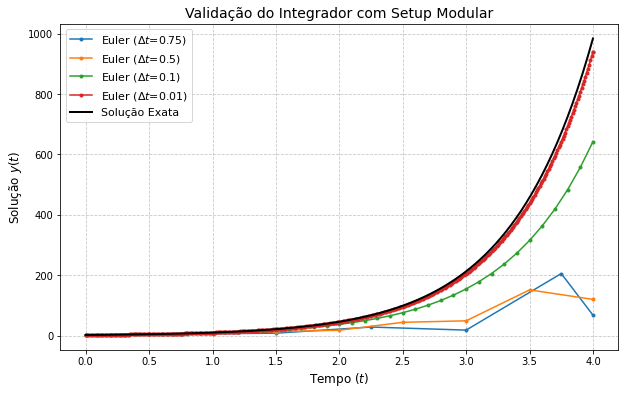

In [36]:
# ====================================================================
# 3. O LOOP DE SIMULAÇÃO SUPER MODULAR
# ====================================================================
t_inicial = 0.0
t_final = 4.0
passos_dt = [0.75, 0.5, 0.1, 0.01] 

plt.figure(figsize=(10, 6))

# Escolha o problema AQUI! O resto do código não muda.
#U0_base, Lh, sol_exata = setup_exponencial()
# U0_base, Lh, sol_exata = setup_logistico()
U0_base, Lh, sol_exata = setup_sistema_edo()

for dt_teste in passos_dt:
    
    # Precisamos de uma cópia limpa da condição inicial para cada teste de dt
    U = [u.copy() for u in U0_base]
    
    t = t_inicial
    dt = dt_teste
    
    historico_t = [t]
    # Guardamos sempre a variável primária (índice 0)
    historico_y = [U[0][0]]
    
    while t < t_final:
        if t + dt > t_final:
            dt = t_final - t
            
        U = Euler_Step(U, t, dt, Lh)
        t += dt
        
        historico_t.append(t)
        historico_y.append(U[0][0])
        
    plt.plot(historico_t, historico_y, marker='o', markersize=3, label=f'Euler ($\Delta t$={dt_teste})')

# Estética
# Plot da solução analítica de forma genérica
t_plot = np.linspace(t_inicial, t_final, 100)
plt.plot(t_plot, sol_exata(t_plot), 'k-', linewidth=2, label='Solução Exata')
plt.title('Validação do Integrador com Setup Modular', fontsize=14)
plt.xlabel('Tempo ($t$)', fontsize=12)
plt.ylabel('Solução $y(t)$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.show()

## **Runge-Kutta 4**

Para contornar as severas limitações de precisão do método de Euler explícito, o padrão ouro na integração de EDOs suaves é a família de métodos de Runge-Kutta. O mais famoso e amplamente adotado deles é o RK4 Clássico.Ao invés de dar um salto cego usando apenas a derivada do início do passo (como faz Euler), o RK4 "sonda" a trajetória da função em pontos intermediários antes de dar o passo definitivo. Matematicamente, para ir do instante $t^n$ para $t^{n+1}$, o método avalia o operador espacial quatro vezes:

$$\begin{align*}  k_1 &= L_h(\mathbf{U}^n) \\  k_2 &= L_h\left(\mathbf{U}^n + \frac{\Delta t}{2} k_1\right) \\  k_3 &= L_h\left(\mathbf{U}^n + \frac{\Delta t}{2} k_2\right) \\  k_4 &= L_h(\mathbf{U}^n + \Delta t k_3)  \end{align*}$$

A Intuição Geométrica dos Estágios:
* $k_1$: É a inclinação no início do intervalo (exatamente o método de Euler).
* $k_2$: É a inclinação no ponto médio do intervalo, usando a inclinação $k_1$ para "adivinhar" o valor da solução no meio do caminho.
* $k_3$: É uma nova inclinação no ponto médio, mas agora usando a inclinação $k_2$ (que é melhor que $k_1$) para recalcular o estado intermediário.
* $k_4$: É a inclinação no final do intervalo, estimando o estado final através da inclinação $k_3$.

Após avaliar essas quatro "inclinações", o passo definitivo no tempo é dado por uma média ponderada estritamente inspirada na Regra de Simpson de integração numérica, dando maior peso (peso 2) às avaliações centrais:

$$\mathbf{U}^{n+1} = \mathbf{U}^n + \frac{\Delta t}{6} (k_1 + 2k_2 + 2k_3 + k_4)$$

### **Exemplo com RK4**

Para vermos o abismo de diferença entre a 1ª e a 4ª ordem de precisão, vamos aplicar o RK4 no mesmo problema escalar que usamos para o método de Euler:

$$\frac{dy}{dt} = y \hspace{1cm} \text{com} \hspace{1cm} y(0) = 1.0$$

O nosso operador espacial continua sendo $L_h(y^n) = y^n$.

Vamos tentar avançar um único e gigantesco passo de tempo $\Delta t = 0.5$.

**Passo 1 (Sondando o intervalo):**
* $k_1 = L_h(1.0) = \mathbf{1.0}$
* $k_2 = L_h(1.0 + 0.25 \times 1.0) = L_h(1.25) = \mathbf{1.25}$
* $k_3 = L_h(1.0 + 0.25 \times 1.25) = L_h(1.3125) = \mathbf{1.3125}$
* $k_4 = L_h(1.0 + 0.5 \times 1.3125) = L_h(1.65625) = \mathbf{1.65625}$

Avanço no Tempo:

$$ y_1 = y_0 + \frac{0.5}{6} \left[ 1.0 + 2(1.25) + 2(1.3125) + 1.65625 \right]$$

$$y_1 = 1.0 + \frac{0.5}{6} \left[ 7.78125 \right] = 1.0 + 0.6484375 = \mathbf{1.6484375}$$

<div align="center">

| Método | Passo (Δt) | Valor Calculado| Valor Exato $(e^{0.5})$| Erro Absoluto|
|:-----:|:-----:|:-----:|:-----:|:-----:|
|Euler (1ª Ordem)|0.5 |1.5000000 |1.6487213 | 0.1487213 |
|RK4 (4ª Ordem)| 0.5 | 1.6484375| 1.6487213 | 0.0002838 |

</div>

Vamos gerar o resto da tabela até o tempo $t = 4$ com simples código para avaliarmos a precisão do RK4

In [ ]:
import numpy as np

delta_t = 0.5
t = np.linspace(0, 4, int(4/delta_t) + 1)
y = np.zeros(len(t))

# Cabeçalho da tabela em Markdown
print("| Tempo (t) | Numérico (RK4) | Exato ($e^t$) | Erro Absoluto $\|y_{num} - y_{exato}\|$ |")
print("|:----:|:----:|:----:|:----:|")

for i in range(len(t)):
    if i == 0:
        y[i] = 1.0
    else:
        # Nossa EDO: dy/dt = Lh(y) = y
        # Avaliando os 4 estágios baseados no valor do passo anterior y[i-1]
        k1 = y[i-1]
        k2 = y[i-1] + (delta_t / 2.0) * k1
        k3 = y[i-1] + (delta_t / 2.0) * k2
        k4 = y[i-1] + delta_t * k3
        
        # Avançando no tempo
        y[i] = y[i-1] + (delta_t / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    
    # Calculando a solução exata e o erro
    y_exato = np.exp(t[i])
    erro = abs(y[i] - y_exato)
    
    # Print formatado para a tabela (com 5 casas decimais de precisão)
    print(f"| {t[i]:.1f} | {y[i]:.5f} | {y_exato:.5f} | {erro:.5f} |")

<div align="center">

| Tempo (t) | Numérico (RK4) | Exato ($e^t$) | Erro Absoluto $\|y_{num} - y_{exato}\|$ |
|:----:|:----:|:----:|:----:|
| 0.0 | 1.00000 | 1.00000 | 0.00000 |
| 0.5 | 1.64844 | 1.64872 | 0.00028 |
| 1.0 | 2.71735 | 2.71828 | 0.00094 |
| 1.5 | 4.47938 | 4.48169 | 0.00231 |
| 2.0 | 7.38397 | 7.38906 | 0.00509 |
| 2.5 | 12.17201 | 12.18249 | 0.01048 |
| 3.0 | 20.06480 | 20.08554 | 0.02073 |
| 3.5 | 33.07557 | 33.11545 | 0.03988 |
| 4.0 | 54.52302 | 54.59815 | 0.07513 |

</div>

O RK4 é, de fato, fantástico e amplamente utilizado em problemas de aeroacústica linear ou em simulações de fluidos perfeitamente suaves. Porém, em problemas hiperbólicos não-lineares da fluidodinâmica compressível (como nas Equações de Euler ou Burgers), a física exige a formação de choques e descontinuidades.

A teoria matemática nos diz que o RK4 clássico, embora absurdamente preciso para funções contínuas, não preserva certas propriedades de estabilidade não-linear (a propriedade Total Variation Diminishing - TVD). Próximo a descontinuidades severas, as sondagens internas ($k_2, k_3$) podem ler "degraus" espúrios e introduzir oscilações numéricas indesejadas, mesmo que o operador espacial $L_h$ já possua dissipação adequada vinda dos nossos fluxos numéricos ou limitadores de inclinação.

Para resolver esse problema sem sacrificar a estabilidade próximo a choques, precisamos usar integradores de tempo que sejam matematicamente blindados para não gerar oscilações novas. Isso nos leva a uma classe especial de esquemas temporais criados especificamente para o Método DG: os métodos **SSP (Strong Stability Preserving)**.

### **Codando o RK4**

In [38]:
import numpy as np
from typing import Callable, List, Optional

def RK4_Step(
    U_modal: List[np.ndarray], 
    t: float, 
    dt: float, 
    Lh_operator: Callable, 
    limiter_func: Optional[Callable] = None
) -> List[np.ndarray]:
    """
    Avança a solução em um passo de tempo usando o Método RK4 Clássico.
    Agnóstico à física e capaz de lidar com N equações acopladas.
    """
    num_vars = len(U_modal)
    
    # Helper interno para aplicar o limitador a todas as variáveis da lista
    def apply_limiter(U_state):
        if limiter_func is not None:
            return [limiter_func(u) for u in U_state]
        return U_state

    # Estágio 1 (k1) - Sondagem inicial
    k1 = Lh_operator(U_modal, t)
    
    U1 = [U_modal[i] + 0.5 * dt * k1[i] for i in range(num_vars)]
    U1 = apply_limiter(U1)
    
    # Estágio 2 (k2) - Sondagem no ponto médio
    k2 = Lh_operator(U1, t + 0.5 * dt)
    
    U2 = [U_modal[i] + 0.5 * dt * k2[i] for i in range(num_vars)]
    U2 = apply_limiter(U2)
    
    # Estágio 3 (k3) - Nova sondagem no ponto médio
    k3 = Lh_operator(U2, t + 0.5 * dt)
    
    U3 = [U_modal[i] + dt * k3[i] for i in range(num_vars)]
    U3 = apply_limiter(U3)
    
    # Estágio 4 (k4) - Sondagem no final do passo
    k4 = Lh_operator(U3, t + dt)
    
    # Avanço no Tempo (Média Ponderada)
    U_new = [
        U_modal[i] + (dt / 6.0) * (k1[i] + 2.0 * k2[i] + 2.0 * k3[i] + k4[i])
        for i in range(num_vars)
    ]
    U_new = apply_limiter(U_new)
    
    return U_new

#### **Testando o código**

Para testar o nosso código vamos resolver três problemas:

**Problema 1**

$$\frac{dy}{dt} = y \hspace{2cm} y_0 = 1 \hspace{2cm}  y_{exato} = e^t$$

**Problema 2**

$$\frac{dy}{dt} = y(1-y) \hspace{2cm} y_0 = 0.1 \hspace{2cm} y_{exato} = \dfrac{1}{1 + 9e^{-t}}$$

**Problema 3**
$$y'' + 5y' - 10y = sin(t) \hspace{2cm} y_0 = 2 \ ; \ y'_0 = 4 \\ 
y_{exato} = \left( \frac{297}{292} + \frac{2675}{292\sqrt{65}} \right) e^{\left(\frac{-5 + \sqrt{65}}{2}\right)t} + \left( \frac{297}{292} - \frac{2675}{292\sqrt{65}} \right) e^{\left(\frac{-5 - \sqrt{65}}{2}\right)t} - \frac{5}{146} \cos(t) - \frac{11}{146} \sin(t)$$

In [39]:
import matplotlib.pyplot as plt

# Reutilizando nossos Setups anteriores
def setup_exponencial():
    U0 = [np.array([1.0])]
    def Lh(U_modal, t): return [U_modal[0]]
    def sol_exata(t): return np.exp(t)
    return U0, Lh, sol_exata

def setup_logistico():
    """ Problema 2: Crescimento Logístico (dy/dt = y*(1-y), y(0)=0.1) """
    U0 = [np.array([0.1])]
    
    def Lh(U_modal, t):
        y = U_modal[0]
        return [y * (1.0 - y)]
        
    def sol_exata(t):
        # Solução analítica: y(t) = 1 / (1 + 9*e^(-t))
        return 1.0 / (1.0 + 9.0 * np.exp(-t))
        
    return U0, Lh, sol_exata

def setup_sistema_edo():
    U0 = [np.array([2.0]), np.array([4.0])]
    def Lh(U_modal, t):
        x1, x2 = U_modal[0], U_modal[1]
        return [x2, -5.0 * x2 + 10.0 * x1 + np.sin(t)]
    def sol_exata(t):
        r65 = np.sqrt(65.0)
        c1 = (297.0 / 292.0) + (2675.0 / (292.0 * r65))
        c2 = (297.0 / 292.0) - (2675.0 / (292.0 * r65))
        return (c1 * np.exp((-5.0 + r65)/2.0 * t) + 
                c2 * np.exp((-5.0 - r65)/2.0 * t) - 
                (5.0/146.0)*np.cos(t) - (11.0/146.0)*np.sin(t))
    return U0, Lh, sol_exata



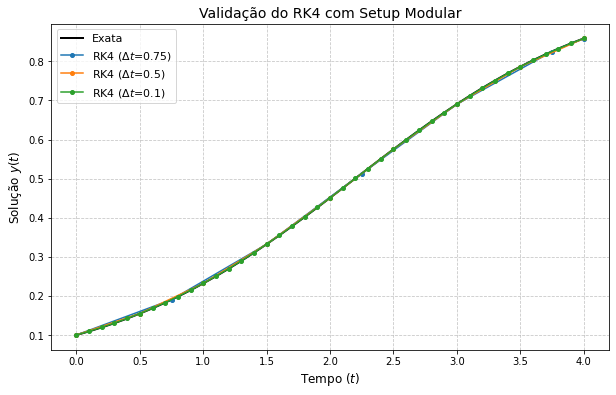

In [42]:
# ====================================================================
# LOOP DE SIMULAÇÃO 
# ====================================================================
t_inicial = 0.0
t_final = 4.0
passos_dt = [0.75, 0.5, 0.1] 

plt.figure(figsize=(10, 6))

# Trocando a física com uma única linha!
# U0_base, Lh, sol_exata = setup_exponencial()
U0_base, Lh, sol_exata = setup_logistico()
# U0_base, Lh, sol_exata = setup_sistema_edo()

# Plot da solução analítica (Curva preta)
t_plot = np.linspace(t_inicial, t_final, 100)
plt.plot(t_plot, sol_exata(t_plot), 'k-', linewidth=2, label='Exata')

for dt_teste in passos_dt:
    U = [u.copy() for u in U0_base]
    t = t_inicial
    dt = dt_teste
    
    historico_t = [t]
    historico_y = [U[0][0]]
    
    while t < t_final:
        if t + dt > t_final:
            dt = t_final - t
            
        # O Motor da simulação agora chama o RK4
        U = RK4_Step(U, t, dt, Lh)
        t += dt
        
        historico_t.append(t)
        historico_y.append(U[0][0])
        
    plt.plot(historico_t, historico_y, marker='o', markersize=4, label=f'RK4 ($\Delta t$={dt_teste})')

plt.title('Validação do RK4 com Setup Modular', fontsize=14)
plt.xlabel('Tempo ($t$)', fontsize=12)
plt.ylabel('Solução $y(t)$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.show()

### **Propriedade TVD (Total Variation Diminishing)**

Vimos que o RK4 Clássico é extremamente preciso, mas pode gerar oscilações (o famoso blow-up numérico ou o Fenômeno de Gibbs) perto de choques. Isso ocorre porque ele não garante a estabilidade não-linear da equação.

Para que um método numérico seja fisicamente aceitável em escoamentos compressíveis, ele não pode criar novos extremos locais na solução — ou seja, a "variação total" da onda não pode aumentar com o tempo. Se o Método de Euler Explícito obedece a essa propriedade (sob uma restrição rígida de passo de tempo $\Delta t$), a nossa missão é construir um método de ordem mais alta que seja apenas uma combinação convexa de passos de Euler.  

Se somarmos passos de Euler usando apenas coeficientes positivos que somam 1, a propriedade TVD do Euler é transmitida para o método final. Essa é a base dos esquemas Strong Stability Preserving (SSP).

## **Métodos RKTVD / RKSSP**

### **Dedução Caso de 2ª Ordem**

Na **aula 00** foi comentado que existem formas de integração distintas da família RKSSP, uma delas e que foi mostrada de forma breve é a de 2ª ordem:

$$\begin{align*}
\{c_{i}\}^{*}=& \ \{c_{i}\}^{(t)}+\Delta t\partial_{t}\{c_{i}\}^{(t)} \\
\{c_{i}\}^{(t+\Delta t)}=& \ \frac{1}{2}\{c_{i}\}^{(t)}+ \frac{1}{2} \{c_{i}\}^{*}+ \frac{1}{2} \Delta t\partial_{t}\{c_{i}\}^{*}
\end{align*}
$$

Para entender como essa e outras estratégias de ordens mais altas são forjadas, precisamos olhar para a forma geral de Runge-Kutta escrita na famosa representação de Shu-Osher:

$$\begin{align*} 
u^{(0)} &= u^n \\ 
u^{(i)} &= \sum_{j=0}^{i-1} \left( \alpha_{ij} u^{(j)} + \Delta t \beta_{ij} L(u^{(j)}) \right), \quad 1 \le i \le m \\ 
u^{n+1} &= u^{(m)} 
\end{align*}$$

em que $L(u) = u_t$.

Para garantir a consistência do método (ou seja, ele realmente avança no tempo corretamente), a soma dos coeficientes de combinação deve ser igual a 1:

$$\sum_{j=0}^{i-1} \alpha_{ij} = 1$$

---

**Construindo o SSP-RK2 (2 Estágios, 2ª Ordem)**

Vamos deduzir o esquema de 2 estágios ($m=2$). O nosso sistema de equações expandido fica: 

$$\begin{align*} 
u^{(1)} &= u^{(0)} + \Delta t \beta_{10} L(u^{(0)}) \\ 
u^{(2)} &= \alpha_{20} u^{(0)} + \alpha_{21} u^{(1)} + \Delta t \beta_{20} L(u^{(0)}) + \Delta t \beta_{21} L(u^{(1)}) 
\end{align*}$$

Da regra de consistência, sabemos imediatamente que $\alpha_{20} + \alpha_{21} = 1$, o que nos dá $\alpha_{20} = 1 - \alpha_{21}$.

---

**Condição de Ordem (Encontro com a Série de Taylor):**

Para que o método seja verdadeiramente de 2ª Ordem, a sua expansão algébrica deve casar perfeitamente com os coeficientes da Série de Taylor exata até o termo $\Delta t^2$. 

Seja a EDO: 
$$\dfrac{du}{dt} = L(u)$$

A expansão de Taylor exata de $t^n$ para $t^{n+1} = t^n + \Delta t$:
$$u(t^{n+1}) = u(t^n) + \Delta t \dfrac{du}{dt}(t^n) + \dfrac{\Delta t^2}{2} \dfrac{d^2u}{dt^2}(t^n) + \mathcal{O}(t^3)$$

sabemos que $\dfrac{du}{dt} = L(u)$ logo:
$$\dfrac{d^2u}{dt^2} = \dfrac{d}{dt} \Big (\dfrac{du}{dt} \Big) = \dfrac{d}{dt}(L(u)) = \frac{\partial L}{\partial u} \frac{du}{dt} = \frac{\partial L}{\partial u} L(u) =  L_u L(u)$$

chamando $L(u(t^n)) = L^n$ e $L_u(u(t^n)) = L^n_u$

$$u^{n+1} = u^n + \Delta t L^n + \frac{\Delta t^2}{2} L_u^n L^n$$

relembrando nossas equações:
$$\begin{align*} 
u^{(1)} &= u^{(0)} + \Delta t \beta_{10} L(u^{(0)}) \\ 
u^{(2)} &= \alpha_{20} u^{(0)} + \alpha_{21} u^{(1)} + \Delta t \beta_{20} L(u^{(0)}) + \Delta t \beta_{21} L(u^{(1)}) 
\end{align*}$$

como $n$ é o tempo conhecido na expansão de Taylor, ele é equivalente ao $(0)$ das nossas equações, além disso como escolhemos **2 estágios** o $ u^{(2)} = u^{(n+1)} $, portanto:
$$\begin{align*} 
u^{(1)} &= u^{(n)} + \Delta t \beta_{10} L(u^{(n)}) \\ 
u^{(n+1)} &= \alpha_{20} u^{(n)} + \alpha_{21} u^{(1)} + \Delta t \beta_{20} L(u^{(n)}) + \Delta t \beta_{21} L(u^{(1)}) 
\end{align*}$$

temos ainda:
$$L(u^{(1)}) = L(u^{(n)} + \Delta t \beta_{10} L(u^{(n)})) \approx L^n + \Delta t \beta_{10} L_u^n L^n$$

substituindo:
$$u^{(n+1)} = \alpha_{20} u^{(n)} + \alpha_{21} (u^{(n)} + \Delta t \beta_{10} L^{n}) + \Delta t \beta_{20} L^n + \Delta t \beta_{21} [L^n + \Delta t \beta_{10} L_u^n L^n]$$

agrupando os termos semelhantes e detacando os coeficientes da Série de Taylor:
$$u^{(n+1)} = \underbrace{(\alpha_{20} + \alpha_{21})}_{1} u^n + \Delta t \underbrace{(\alpha_{21}\beta_{10} + \beta_{20} + \beta_{21})}_{1} L^n + \Delta t^2 \underbrace{(\beta_{10}\beta_{21})}_{{1}/{2}} L_u^n L^n$$

Chegamos às famosas "Condições de Ordem":  
$$\alpha_{20} + \alpha_{21} = 1 \hspace{2cm} \alpha_{21} \beta_{10} + \beta_{20} + \beta_{21} = 1 \hspace{2cm} \beta_{21} \beta_{10} = \frac{1}{2}$$

---

**O Problema de Otimização (Maximizando o CFL):**

Vamos tomar como índice livre $\beta_{10}$ e $\alpha_{21}$
$$
\begin{align*}
\alpha_{20} = & \ 1 - \alpha_{21} \\
\beta_{21} = & \ \dfrac{1}{2 \beta_{10}} \\
\beta_{20} = & \ 1 - \dfrac{1}{2 \beta_{10}} - \alpha_{21} \beta_{10}
\end{align*}
$$

Temos um sistema com 3 equações e 5 variáveis ($\alpha_{20}, \alpha_{21}, \beta_{10}, \beta_{20}, \beta_{21}$).  

Como queremos a maior estabilidade possível, formulamos um **problema de otimização** para encontrar o maior passo de tempo permitido. Tal estabilidade é garantida caso
$$ \Delta t \leq C \Delta t_{foward-Euler}$$

e o parâmetro $C$ é definido como:

$$C = \min_{i,j} \frac{\alpha_{ij}}{\beta_{ij}}$$

Com base na literatura $C=1$ é o ótimo para esse problema, então os coeficientes ótimos são: 

* $\alpha_{10} = 1$ e $\beta_{10} = 1$
* $\alpha_{21} = \dfrac{1}{2}$ e $\beta_{21} = \dfrac{1}{2}$
* $\alpha_{20} = \dfrac{1}{2}$ e $\beta_{20} = 0$

**Esquema Final:**  

Substituindo esses coeficientes de volta nas nossas equações de Shu-Osher, revelamos o método SSP-RK2 apresentado na **aula 00**:  

$$\begin{align*} 
u^{(1)} &= u^n + \Delta t L(u^n) \\ 
u^{n+1} &= \frac{1}{2} u^n + \frac{1}{2} u^{(1)} + \frac{1}{2} \Delta t L(u^{(1)}) 
\end{align*}$$

Note a beleza dessa formulação: o primeiro estágio ($u^{(1)}$) é puramente um passo de Euler Explícito. O segundo estágio é a média (combinação convexa) entre o estado inicial $u^n$ e um novo passo de Euler dado a partir de $u^{(1)}$. Sendo médias de passos de Euler, a propriedade TVD está garantida!